In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read data

In [3]:
health_df = pd.read_csv("../data/healthcare_disease_prediction_dataset.csv")
health_df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0


# EDA

In [4]:
health_df.dtypes

Age                      int64
Gender                  object
Blood Pressure          object
Cholesterol             object
Glucose                 object
Smoking                 object
Alcohol Consumption     object
Exercise                object
BMI                    float64
Family History          object
Heart Disease            int64
Diabetes                 int64
Stroke                   int64
Kidney Disease           int64
Cancer                   int64
Alzheimer's Disease      int64
COPD                     int64
Liver Disease            int64
Parkinson's Disease      int64
Tuberculosis             int64
dtype: object

In [5]:
# Convert multiple columns to string
columns_to_convert = ["Heart Disease", "Diabetes", "Stroke", "Kidney Disease", "Cancer", "Alzheimer's Disease", "COPD", "Liver Disease", "Parkinson's Disease", "Tuberculosis"]
health_df[columns_to_convert] = health_df[columns_to_convert].astype(bool)

health_df.dtypes

Age                      int64
Gender                  object
Blood Pressure          object
Cholesterol             object
Glucose                 object
Smoking                 object
Alcohol Consumption     object
Exercise                object
BMI                    float64
Family History          object
Heart Disease             bool
Diabetes                  bool
Stroke                    bool
Kidney Disease            bool
Cancer                    bool
Alzheimer's Disease       bool
COPD                      bool
Liver Disease             bool
Parkinson's Disease       bool
Tuberculosis              bool
dtype: object

In [6]:
health_df[["Age", "BMI"]].describe()

,Age,BMI
count,1000.000000,1000.000000
mean,52.881000,29.213037
std,20.958915,6.196368
min,18.000000,18.504881
25%,34.750000,23.924004
50%,52.500000,28.892349
75%,71.000000,34.663806
max,89.000000,39.974048


In [7]:
health_df.isna().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

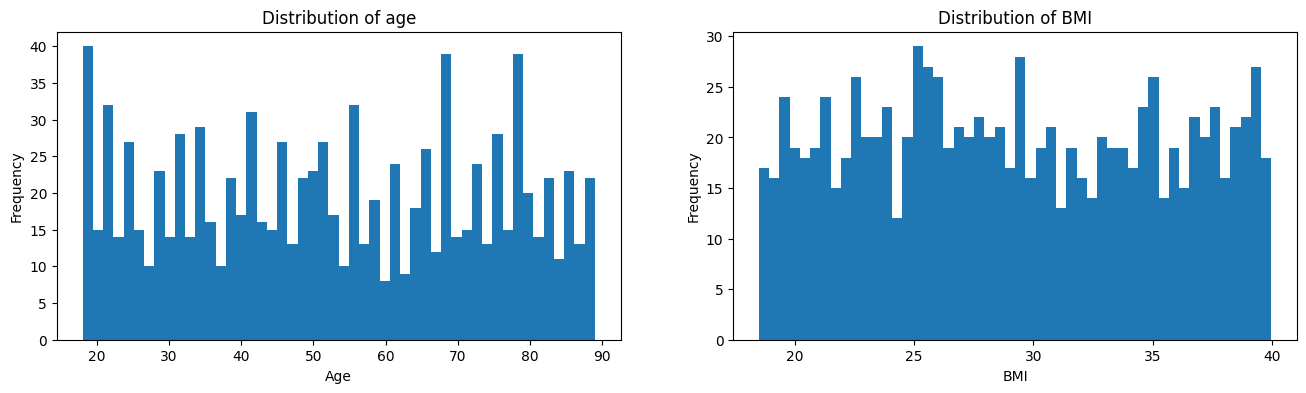

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(health_df["Age"], bins=50)
axes[0].set_title("Distribution of age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

axes[1].hist(health_df["BMI"], bins=50)
axes[1].set_title("Distribution of BMI")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Frequency")

plt.show()

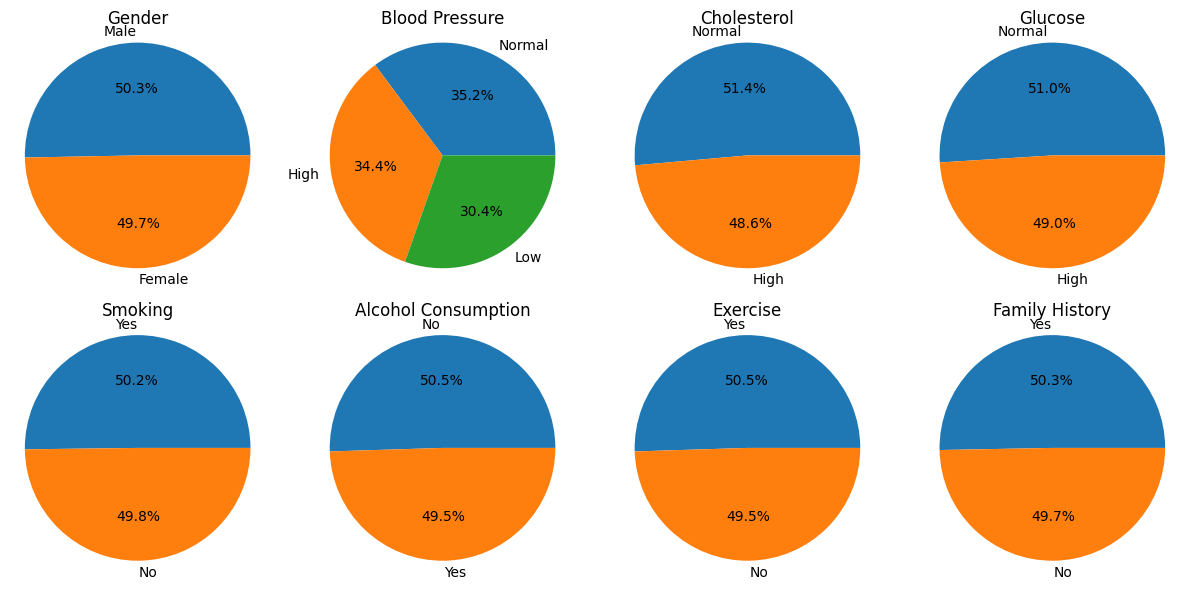

In [9]:
input_cat_cols = ["Gender", "Blood Pressure", "Cholesterol", "Glucose", "Smoking", "Alcohol Consumption", "Exercise", "Family History"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = np.array(axes).ravel()

for ax, col in zip(axes, input_cat_cols):
    counts = health_df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
    ax.set_title(col)
    ax.axis("equal")

for ax in axes[len(input_cat_cols) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()


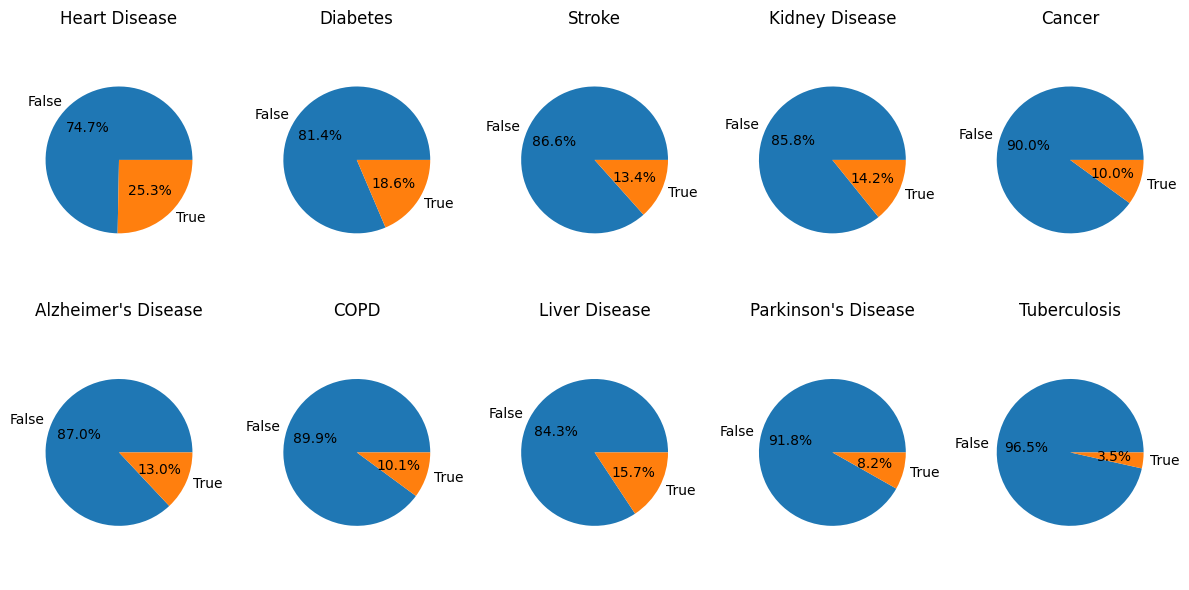

In [10]:
output_cat_cols = ["Heart Disease", "Diabetes", "Stroke", "Kidney Disease", "Cancer", "Alzheimer's Disease", "COPD", "Liver Disease", "Parkinson's Disease", "Tuberculosis"]

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = np.array(axes).ravel()

for ax, col in zip(axes, output_cat_cols):
    counts = health_df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
    ax.set_title(col)
    ax.axis("equal")

for ax in axes[len(output_cat_cols) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()